## SpaceShip Titanic 

Réalisé par : Imane BOUKHARI,
Lynda CHABOUNI,
Léo BEN HATAT,
Khady CAMARA DANSO

# 1. Etude préalable des données 
## 1.1. Analyse des fichiers 

Librairies et extensions 

In [95]:
import pandas as pd  # pandas is used for data manipulation and analysis, providing data structures like DataFrames.
import numpy as np  # numpy is used for numerical operations on large, multi-dimensional arrays and matrices.
import seaborn as sns  # seaborn is used for making statistical graphics in Python.
import matplotlib.pyplot as plt # matplotlib.pyplot is used for creating static, interactive, and animated visualizations in Python.
from matplotlib.ticker import FuncFormatter  # FuncFormatter is used for formatting tick labels on matplotlib plots.

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

from scipy.stats import chi2_contingency
sns.set(style="whitegrid")


COLORS = {
    'cyan':   '#00d4ff', 'red':  '#ff6b6b', 'green': '#7fff7f',
    'amber':  '#ffcc44', 'purple':'#b77fff', 'muted': '#6080a0',
    'bg':     '#070b14', 'bg2':  '#0d1626', 'bg3':   '#152035',
    'text':   '#c8d8f0', 'border':'#1e3050'
}
CLUSTER_COLORS = [COLORS['cyan'], COLORS['red'], COLORS['green'],
                  COLORS['amber'], COLORS['purple']]

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],  'axes.facecolor':  COLORS['bg2'],
    'axes.edgecolor':   COLORS['border'], 'axes.labelcolor': COLORS['text'],
    'xtick.color':      COLORS['muted'], 'ytick.color':     COLORS['muted'],
    'text.color':       COLORS['text'],  'grid.color':      COLORS['border'],
    'grid.linestyle':   '--',            'grid.alpha':      0.4,
})


print("✓ Imports et configuration OK")


✓ Imports et configuration OK


Importation des données

In [96]:
chemin = 'Données/train.csv'
train_data = pd.read_csv(chemin)

chemin = 'Données/test.csv'
test_data = pd.read_csv(chemin)

display(train_data.head())
print(f'The shape of the train dataset is {train_data.shape}')
print(f'The shape of the test dataset is {test_data.shape}\n')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


The shape of the train dataset is (8693, 14)
The shape of the test dataset is (4277, 13)



Liste des variables présentes dans le dataset

| **Nom de la variable** | **Description** |
|:----------------------:|:---------------:|
| PassengerId | Un identifiant unique pour chaque passager. Chaque identifiant prend la forme de gggg_pp, où gggg indique le groupe avec lequel le passager voyage et pp est son numéro au sein du groupe. Les membres d'un groupe sont souvent des membres de la famille, mais pas toujours. |
| HomePlanet | La planète d'où le passager est parti, généralement sa planète de résidence permanente. |
| CryoSleep | Indique si le passager a choisi d'être mis en animation suspendue pendant la durée du voyage. Les passagers en cryosleep sont confinés dans leurs cabines. |
| Cabin | Le numéro de cabine où le passager séjourne. Il prend la forme de pont/numéro/côté, où le côté peut être soit P pour bâbord, soit S pour tribord. (deck/num/side) |
| Destination | Planète de destination |
| Age | Âge du passager |
| VIP | Indique si le passager a payé pour un service VIP spécial pendant le voyage. |
| RoomService | Dépenses en Room Service |
| FoodCourt | Dépenses au Food Court |
| ShoppingMall | Dépenses au Shopping Mall |
| Spa | Dépenses au Spa |
| VRDeck | Dépenses au VR Deck |
| Name | Prénom et nom du passager |
| Transported |  Indique si le passager a été transporté vers une autre dimension. Il s'agit de la cible, la colonne que vous essayez de prédire. |

# 1.2 Traitement des valeurs manquantes et aberrantes

In [97]:
# Statistiques descriptives globales
stats = train_data.describe(include='all').T
stats['% de valeurs manquantes'] = 100 * train_data.isnull().sum() / len(train_data)
display(stats)

# Tableau synthétique des valeurs manquantes
manquantes = pd.DataFrame({
    'Nom': train_data.columns,
    'Total de valeurs': len(train_data),
    'Total de valeurs manquantes': train_data.isnull().sum().values,
    'Pourcentage de valeurs manquantes': 100 * train_data.isnull().sum().values / len(train_data)
})
manquantes = manquantes[manquantes['Total de valeurs manquantes'] > 0]
manquantes = manquantes[['Nom', 'Total de valeurs', 'Total de valeurs manquantes', 'Pourcentage de valeurs manquantes']]
manquantes.sort_values('Total de valeurs manquantes', ascending=False, inplace=True)
display(manquantes.style.format({'Pourcentage de valeurs manquantes': '{:.2f}%'}).set_caption('Valeurs manquantes par variable'))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,% de valeurs manquantes
PassengerId,8693,8693,0001_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
HomePlanet,8492,3,Earth,4602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.312205
CryoSleep,8476,2,False,5439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.496261
Cabin,8494,6560,G/734/S,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.289198
Destination,8511,3,TRAPPIST-1e,5915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.093639
Age,8514.0,NaN,NaN,NaN,28.82793,14.489021,0.0,19.0,27.0,38.0,79.0,2.059128
VIP,8490,2,False,8291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.335212
RoomService,8512.0,NaN,NaN,NaN,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0,2.082135
FoodCourt,8510.0,NaN,NaN,NaN,458.077203,1611.48924,0.0,0.0,0.0,76.0,29813.0,2.105142
ShoppingMall,8485.0,NaN,NaN,NaN,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0,2.392730


,Nom,Total de valeurs,Total de valeurs manquantes,Pourcentage de valeurs manquantes
2,CryoSleep,8693,217,2.50%
9,ShoppingMall,8693,208,2.39%
6,VIP,8693,203,2.34%
1,HomePlanet,8693,201,2.31%
12,Name,8693,200,2.30%
3,Cabin,8693,199,2.29%
11,VRDeck,8693,188,2.16%
8,FoodCourt,8693,183,2.11%
10,Spa,8693,183,2.11%
4,Destination,8693,182,2.09%


Vérification des doublons

In [98]:
duplicates = train_data.duplicated()
print("\nNumber of duplicates :", duplicates.sum())

if duplicates.any():
    print("\nLines with duplicates :")
    print(train_data[duplicates])


Number of duplicates : 0


Nous visualisons la distribution des variables numériques et détectons les valeurs aberrantes à l'aide de la méthode de l'IQR. Les outliers sont remplacés par la médiane pour préserver la distribution.

In [99]:
num_cols = train_data.select_dtypes(include=np.number).columns
for col in num_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((train_data[col] < lower) | (train_data[col] > upper)).sum()
    print(f"{col} : {outliers} valeurs aberrantes détectées")
    mediane = train_data[col].median()
    train_data.loc[train_data[col] < lower, col] = mediane
    train_data.loc[train_data[col] > upper, col] = mediane

Age : 77 valeurs aberrantes détectées
RoomService : 1861 valeurs aberrantes détectées
FoodCourt : 1823 valeurs aberrantes détectées
ShoppingMall : 1829 valeurs aberrantes détectées
Spa : 1788 valeurs aberrantes détectées
VRDeck : 1809 valeurs aberrantes détectées


In [100]:

# Columnas numéricas
num_cols = train_data.select_dtypes(include=np.number).columns

# Diccionario que guardará las máscaras de outliers por columna
outlier_cols = {}

# Máscara global para filas que son outliers en al menos una columna
outlier_mask = pd.Series(False, index=train_data.index)

for col in num_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (train_data[col] < lower) | (train_data[col] > upper)
    outlier_cols[col] = mask
    outlier_mask = outlier_mask | mask

# DataFrame con todas las filas que tienen al menos un outlier
df_outliers = train_data[outlier_mask].copy()

# Añadir columna que lista las columnas donde cada fila es outlier
df_outliers['OutlierColumns'] = df_outliers.index.to_series().apply(lambda i: [col for col, m in outlier_cols.items() if m.loc[i]])

# Flag booleano
df_outliers

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,OutlierColumns
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,0.0,44.0,Juanna Vines,True,"[RoomService, FoodCourt, ShoppingMall, VRDeck]"
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,0.0,0.0,0.0,49.0,Altark Susent,False,"[RoomService, VRDeck]"
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,0.0,70.0,0.0,0.0,2.0,Willy Santantines,True,"[FoodCourt, VRDeck]"
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,0.0,3.0,0.0,0.0,Billex Jacostaffey,True,"[RoomService, ShoppingMall]"
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,0.0,17.0,0.0,0.0,Andona Beston,True,[ShoppingMall]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8686,9275_02,Europa,False,A/97/P,TRAPPIST-1e,32.0,False,1.0,0.0,0.0,50.0,34.0,Diram Conable,False,"[RoomService, Spa, VRDeck]"
8687,9275_03,Europa,NaN,A/97/P,TRAPPIST-1e,30.0,False,0.0,0.0,0.0,2.0,0.0,Atlasym Conable,True,[Spa]
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,0.0,0.0,0.0,74.0,Gravior Noxnuther,False,[VRDeck]
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,0.0,1.0,0.0,Fayey Connon,True,[Spa]


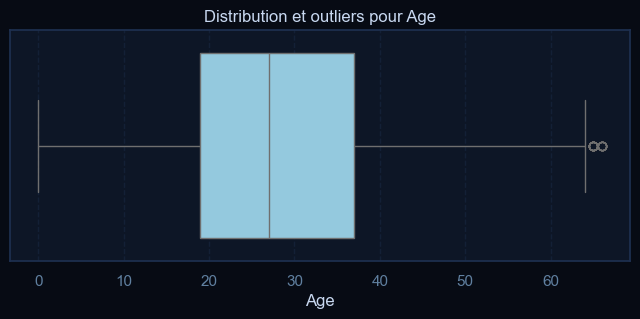

Age : 30 valeurs aberrantes détectées


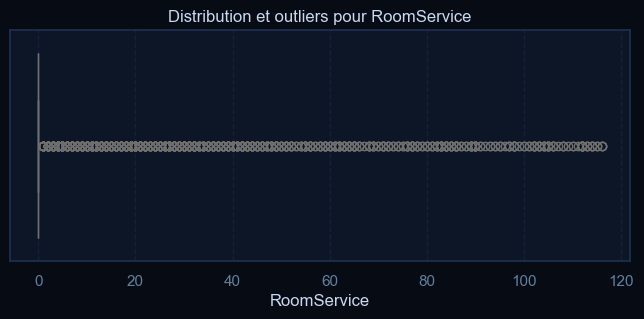

RoomService : 1074 valeurs aberrantes détectées


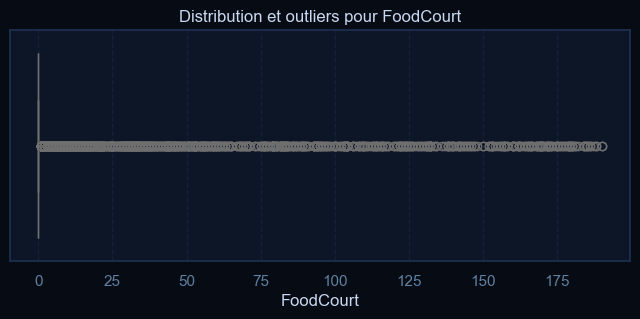

FoodCourt : 1231 valeurs aberrantes détectées


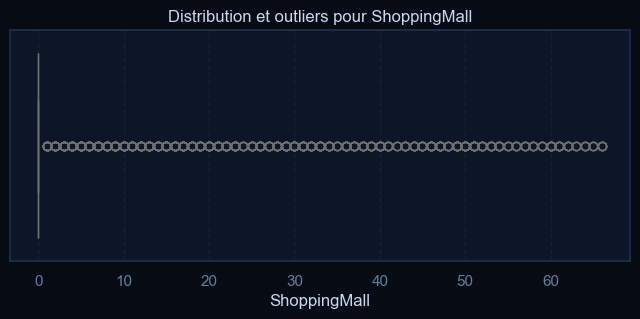

ShoppingMall : 1069 valeurs aberrantes détectées


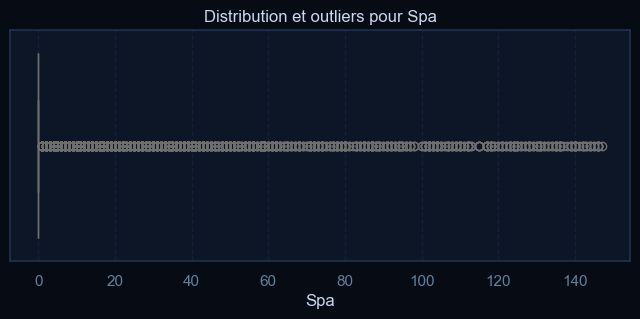

Spa : 1398 valeurs aberrantes détectées


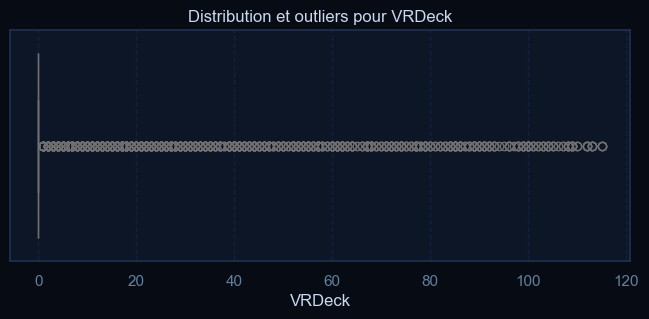

VRDeck : 1201 valeurs aberrantes détectées


In [101]:
num_cols = train_data.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=train_data[col], color='skyblue')
    plt.title(f'Distribution et outliers pour {col}')
    plt.show()
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((train_data[col] < lower) | (train_data[col] > upper)).sum()
    print(f"{col} : {outliers} valeurs aberrantes détectées")
    mediane = train_data[col].median()
    train_data.loc[train_data[col] < lower, col] = mediane
    train_data.loc[train_data[col] > upper, col] = mediane

## 1.3 Variables ajoutées

In [102]:
##########TRAIN  -------------------------------

# A. Exploitation de PassengerId (Group & IsAlone)
train_data['Group'] = train_data['PassengerId'].str.split('_').str[0]
train_data['GroupSize'] = train_data.groupby('Group')['Group'].transform('count')
train_data['IsAlone'] = (train_data['GroupSize'] == 1).astype(int)

# B. Découpage de la cabine (Deck, Num, Side)
train_data[['Deck', 'CabinNum', 'Side']] = train_data['Cabin'].str.split('/', expand=True)

# C. Analyse des dépenses
exp_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_data['TotalSpent'] = train_data[exp_features].sum(axis=1)
train_data['HasSpent']   = (train_data['TotalSpent'] > 0).astype(int)

# D. Nom de famille et taille de la famille
train_data['FamilyName'] = train_data['Name'].str.split().str[-1]
train_data['FamilySize'] = train_data.groupby('FamilyName')['FamilyName'].transform('count')
train_data['HasFamily']  = (train_data['FamilySize'] > 1).astype(int)


##########TEST --------------------------------------

# A. Exploitation de PassengerId (Group & IsAlone)
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]
test_data['GroupSize'] = test_data.groupby('Group')['Group'].transform('count')
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)

# B. Découpage de la cabine (Deck, Num, Side)
test_data[['Deck', 'CabinNum', 'Side']] = test_data['Cabin'].str.split('/', expand=True)

# C. Analyse des dépenses
exp_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test_data['TotalSpent'] = test_data[exp_features].sum(axis=1)
test_data['HasSpent']   = (test_data['TotalSpent'] > 0).astype(int)

# D. Nom de famille et taille de la famille
test_data['FamilyName'] = test_data['Name'].str.split().str[-1]
test_data['FamilySize'] = test_data.groupby('FamilyName')['FamilyName'].transform('count')
test_data['HasFamily']  = (test_data['FamilySize'] > 1).astype(int)

# Drop the Cabin columns
train_data = train_data.drop('Cabin', axis=1)
test_data  = test_data.drop('Cabin', axis=1)

# Vérification rapide
train_data.head()


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,...,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpent,HasSpent,FamilyName,FamilySize,HasFamily
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,...,1,1,B,0,P,0.0,0,Ofracculy,1.0,0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,0.0,0.0,0.0,0.0,...,1,1,F,0,S,0.0,0,Vines,4.0,1
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,0.0,0.0,0.0,0.0,...,2,0,A,0,S,0.0,0,Susent,6.0,1
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,0.0,0.0,0.0,...,2,0,A,0,S,0.0,0,Susent,6.0,1
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,0.0,0.0,0.0,0.0,...,1,1,F,1,S,0.0,0,Santantines,6.0,1


## 1.4 Imputation des valeurs manquantes 

Les valeurs manquantes sont imputées : la médiane pour les variables numériques et la modalité la plus fréquente (mode) pour les variables catégorielles. Cette étape est essentielle pour garantir la qualité des analyses ultérieures.

In [103]:
data = pd.concat([train_data.drop('Transported', axis=1), test_data], ignore_index=True)

#TRAIN 
train_data['HomePlanet'] = train_data['HomePlanet'].fillna(data['HomePlanet'].mode()[0])  # Replace with the mode
train_data['CryoSleep'] = train_data['CryoSleep'].fillna(data['CryoSleep'].mode()[0])  # Replace with the mode
train_data['Destination'] = train_data['Destination'].fillna(data['Destination'].mode()[0])  # Replace with the mode
train_data['Age'] = train_data['Age'].fillna(data['Age'].mean())  # Replace with the mean
train_data['VIP'] = train_data['VIP'].fillna(data['VIP'].mode()[0])  # Replace with the mode, which is False
train_data['RoomService'] = train_data['RoomService'].fillna(data['RoomService'].mean())  # Replace with the mean
train_data['FoodCourt'] = train_data['FoodCourt'].fillna(data['FoodCourt'].mean())  # Replace with the mean
train_data['ShoppingMall'] = train_data['ShoppingMall'].fillna(data['ShoppingMall'].mean())  # Replace with the mean
train_data['Spa'] = train_data['Spa'].fillna(data['Spa'].mean())  # Replace with the mean
train_data['VRDeck'] = train_data['VRDeck'].fillna(data['VRDeck'].mean())  # Replace with the mean

# TEST
test_data['HomePlanet'] = test_data['HomePlanet'].fillna(data['HomePlanet'].mode()[0])  # Replace with the mode
test_data['CryoSleep'] = test_data['CryoSleep'].fillna(data['CryoSleep'].mode()[0])  # Replace with the mode
test_data['Destination'] = test_data['Destination'].fillna(data['Destination'].mode()[0])  # Replace with the mode
test_data['Age'] = test_data['Age'].fillna(data['Age'].mean())  # Replace with the mean
test_data['VIP'] = test_data['VIP'].fillna(data['VIP'].mode()[0])  # Replace with the mode, which is False
test_data['RoomService'] = test_data['RoomService'].fillna(data['RoomService'].mean())  # Replace with the mean
test_data['FoodCourt'] = test_data['FoodCourt'].fillna(data['FoodCourt'].mean())  # Replace with the mean
test_data['ShoppingMall'] = test_data['ShoppingMall'].fillna(data['ShoppingMall'].mean())  # Replace with the mean
test_data['Spa'] = test_data['Spa'].fillna(data['Spa'].mean())  # Replace with the mean
test_data['VRDeck'] = test_data['VRDeck'].fillna(data['VRDeck'].mean())  # Replace with the mean


# Tableau synthétique des valeurs manquantes
manquantes = pd.DataFrame({
    'Nom': train_data.columns,
    'Total de valeurs': len(train_data),
    'Total de valeurs manquantes': train_data.isnull().sum().values,
    'Pourcentage de valeurs manquantes': 100 * train_data.isnull().sum().values / len(train_data)
})
manquantes = manquantes[manquantes['Total de valeurs manquantes'] > 0]
manquantes = manquantes[['Nom', 'Total de valeurs', 'Total de valeurs manquantes', 'Pourcentage de valeurs manquantes']]
manquantes.sort_values('Total de valeurs manquantes', ascending=False, inplace=True)
display(manquantes.style.format({'Pourcentage de valeurs manquantes': '{:.2f}%'}).set_caption('Valeurs manquantes par variable'))

,Nom,Total de valeurs,Total de valeurs manquantes,Pourcentage de valeurs manquantes
11,Name,8693,200,2.30%
21,FamilyName,8693,200,2.30%
22,FamilySize,8693,200,2.30%
16,Deck,8693,199,2.29%
17,CabinNum,8693,199,2.29%
18,Side,8693,199,2.29%


In [104]:
# TRAIN
# Groups where there is someone whose Cabin was missing
indices_groups_missing_cabin = train_data[train_data['Deck'].isnull()]['PassengerId'].values  # PassengerIds of the passengers with the missing cabin

# We can expect that memebers of the same group would share the same cabin deck, 
# number, and side
global_mode = data[['Deck', 'CabinNum', 'Side']].mode().iloc[0]  # Global mode of cabin deck, num, and side

for index in indices_groups_missing_cabin:
    group = index.split('_')[0]  # Number of the group with the member missing the cabin
    group_df = data[data['Group'] == group]  # df with the members of the group
    try:
        # Cabin Deck, Num, and Side mode for each group
        cabin_group_mode = group_df[~group_df['CabinNum'].isnull()][['Deck', 'CabinNum', 'Side']].mode().iloc[0]  
        # Replace the missing CabinNum with the mode in that group
        train_data.loc[train_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = cabin_group_mode.values 
    except IndexError:
        # If there is just one member in a group and it misses the cabin, replace it with the global mode
        train_data.loc[train_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = global_mode.values


# TEST
# Groups where there is someone whose Cabin was missing
indices_groups_missing_cabin = test_data[test_data['Deck'].isnull()]['PassengerId'].values  # PassengerIds of the passengers with the missing cabin

# We can expect that memebers of the same group would share the same cabin deck, 
# number, and side
global_mode = data[['Deck', 'CabinNum', 'Side']].mode().iloc[0]  # Global mode of cabin deck, num, and side

for index in indices_groups_missing_cabin:
    group = index.split('_')[0]  # Number of the group with the member missing the cabin
    group_df = data[data['Group'] == group]  # df with the members of the group
    try:
        # Cabin Deck, Num, and Side mode for each group
        cabin_group_mode = group_df[~group_df['CabinNum'].isnull()][['Deck', 'CabinNum', 'Side']].mode().iloc[0]  
        # Replace the missing CabinNum with the mode in that group
        test_data.loc[test_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = cabin_group_mode.values 
    except IndexError:
        # If there is just one member in a group and it misses the cabin, replace it with the global mode
        test_data.loc[test_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = global_mode.values



In [105]:
# Check
print('Train data\n\n', train_data.isnull().sum(), '\n')
print('Test data\n\n', test_data.isnull().sum())

Train data

 PassengerId       0
HomePlanet        0
CryoSleep         0
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
GroupSize         0
IsAlone           0
Deck              0
CabinNum          0
Side              0
TotalSpent        0
HasSpent          0
FamilyName      200
FamilySize      200
HasFamily         0
dtype: int64 

Test data

 PassengerId      0
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Name            94
Group            0
GroupSize        0
IsAlone          0
Deck             0
CabinNum         0
Side             0
TotalSpent       0
HasSpent         0
FamilyName      94
FamilySize      94
HasFamily        0
dtype: int64


# 1.3 Data types

In [106]:
train_data.dtypes

PassengerId      object
HomePlanet       object
CryoSleep          bool
Destination      object
Age             float64
VIP                bool
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
Group            object
GroupSize         int64
IsAlone           int32
Deck             object
CabinNum         object
Side             object
TotalSpent      float64
HasSpent          int32
FamilyName       object
FamilySize      float64
HasFamily         int32
dtype: object

In [107]:
train_data['Group'] = train_data['Group'].astype(int)
test_data['Group'] = test_data['Group'].astype(int)

train_data['PassengerId'] = train_data['PassengerId'].astype(int)
test_data['PassengerId'] = test_data['PassengerId'].astype(int)

train_data['CryoSleep'] = train_data['CryoSleep'].astype(int)
test_data['CryoSleep'] = test_data['CryoSleep'].astype(int)

train_data['VIP'] = train_data['VIP'].astype(int)
test_data['VIP'] = test_data['VIP'].astype(int)

train_data['CabinNum'] = train_data['CabinNum'].astype(int)
test_data['CabinNum'] = test_data['CabinNum'].astype(int)

train_data['Transported'] = train_data['Transported'].astype(int)

# The values in RoomService, FoodCourt, ShoppingMall, Spa, and VRDeck columns
# are all integers except for the mean values used to replace the missing data.
# So we can set the type of them to int
train_data['RoomService'] = train_data['RoomService'].astype(int)
test_data['RoomService'] = test_data['RoomService'].astype(int)

train_data['FoodCourt'] = train_data['FoodCourt'].astype(int)
test_data['FoodCourt'] = test_data['FoodCourt'].astype(int)

train_data['ShoppingMall'] = train_data['ShoppingMall'].astype(int)
test_data['ShoppingMall'] = test_data['ShoppingMall'].astype(int)

train_data['Spa'] = train_data['Spa'].astype(int)
test_data['Spa'] = test_data['Spa'].astype(int)

train_data['VRDeck'] = train_data['VRDeck'].astype(int)
test_data['VRDeck'] = test_data['VRDeck'].astype(int)


train_data['TotalSpent'] = train_data[exp_features].sum(axis=1)

train_data['HasSpent'] = (train_data['TotalSpent'] > 0).astype(int)
test_data['TotalSpent'] = test_data[exp_features].sum(axis=1)

test_data['HasSpent'] = (test_data['TotalSpent'] > 0).astype(int)


# 2. Statistiques descriptives

## 2.1 Statistiques Univariées

In [108]:
# ══════════════════════════════════════════════════════════════════════════════
# PALETTE — à définir une seule fois en haut de la section EDA
# ══════════════════════════════════════════════════════════════════════════════
COLORS = {
    'bg':     '#0f1117',
    'bg2':    '#161b27',
    'bg3':    '#1e2535',
    'border': '#2a3040',
    'text':   '#cbd5e1',
    'cyan':   '#22d3ee',
    'green':  '#4ade80',
    'amber':  '#fbbf24',
    'red':    '#f87171',
    'purple': '#a78bfa',
    'blue':   '#60a5fa',
    'teal':   '#2dd4bf',
    'pink':   '#f472b6',
}

### 2.1.1 Variables numériques 

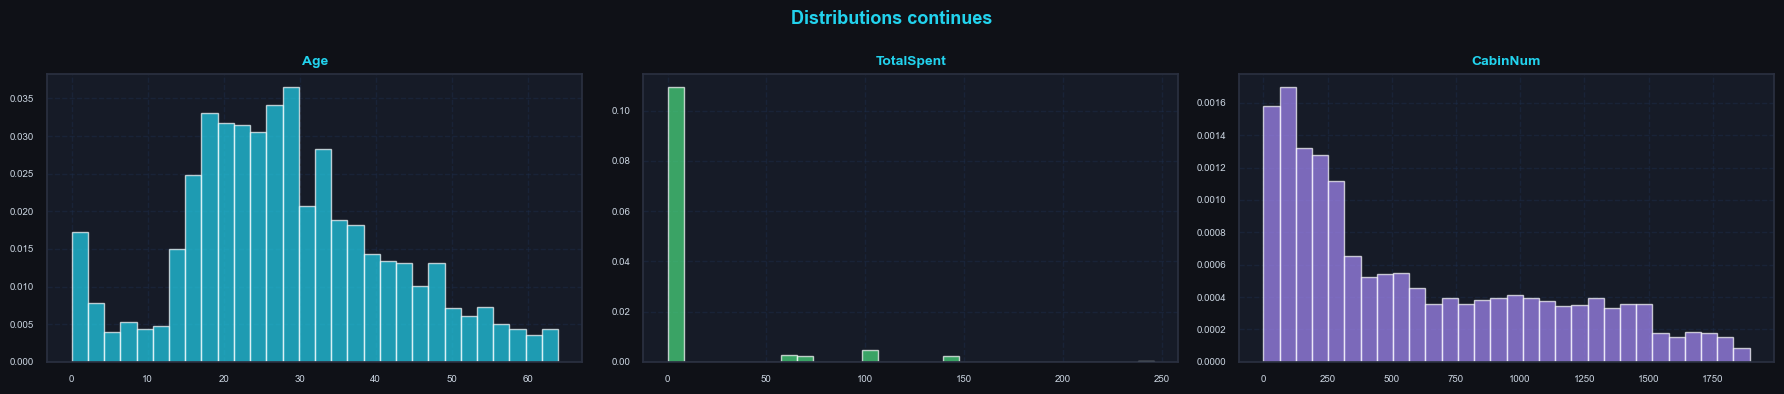

In [109]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. DISTRIBUTIONS CONTINUES  (Age, TotalSpent, CabinNum)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle("Distributions continues", fontsize=13, fontweight='bold', color=COLORS['cyan'])

for ax, (col, color) in zip(axes, [
    ('Age',        COLORS['cyan']),
    ('TotalSpent', COLORS['green']),
    ('CabinNum',   COLORS['purple']),
]):
    vals = train_data[col].dropna().astype(float)
    ax.hist(vals, bins=30, color=color, alpha=0.7, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold', color=COLORS['cyan'])
    ax.tick_params(labelsize=7, colors=COLORS['text'])
    ax.set_facecolor(COLORS['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('eda_cont.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


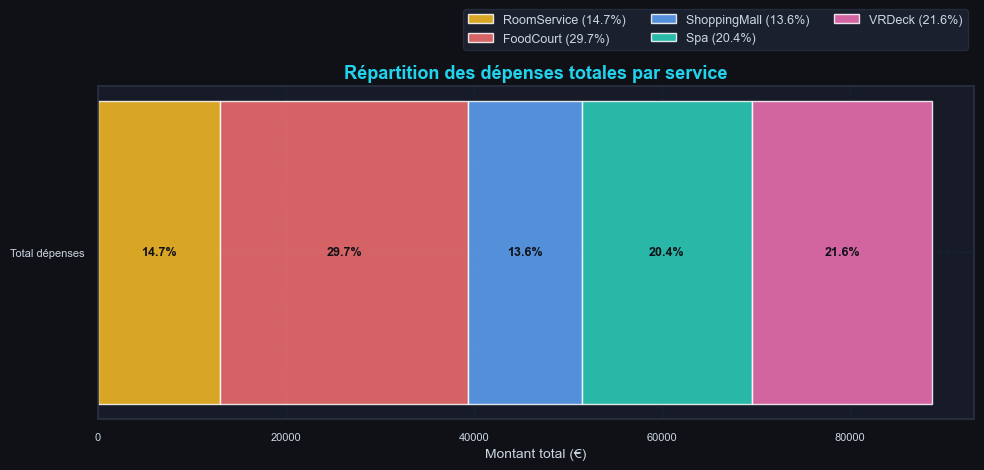

In [110]:

# ══════════════════════════════════════════════════════════════════════════════
# 2. TOTALSPENT — barras apiladas por servicio
# ══════════════════════════════════════════════════════════════════════════════
exp_cols   = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
exp_colors = [COLORS['amber'], COLORS['red'], COLORS['blue'], COLORS['teal'], COLORS['pink']]

service_totals = train_data[exp_cols].sum()
total          = service_totals.sum()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg2'])

left = 0
for col, color in zip(exp_cols, exp_colors):
    val = service_totals[col]
    pct = 100 * val / total
    ax.barh('Total dépenses', val, left=left, color=color, alpha=0.85, label=f"{col} ({pct:.1f}%)")
    ax.text(left + val / 2, 0, f"{pct:.1f}%",
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='#0f1117')
    left += val

ax.set_title("Répartition des dépenses totales par service",
             fontsize=13, fontweight='bold', color=COLORS['cyan'])
ax.tick_params(labelsize=8, colors=COLORS['text'])
ax.legend(fontsize=9, facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
          labelcolor=COLORS['text'], loc='upper right',
          bbox_to_anchor=(1, 1.25), ncol=3)
ax.set_xlabel("Montant total (€)", fontsize=10, color=COLORS['text'])
for spine in ax.spines.values():
    spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('eda_totalspent.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()



### 2.1.2 Variables catégorielles 

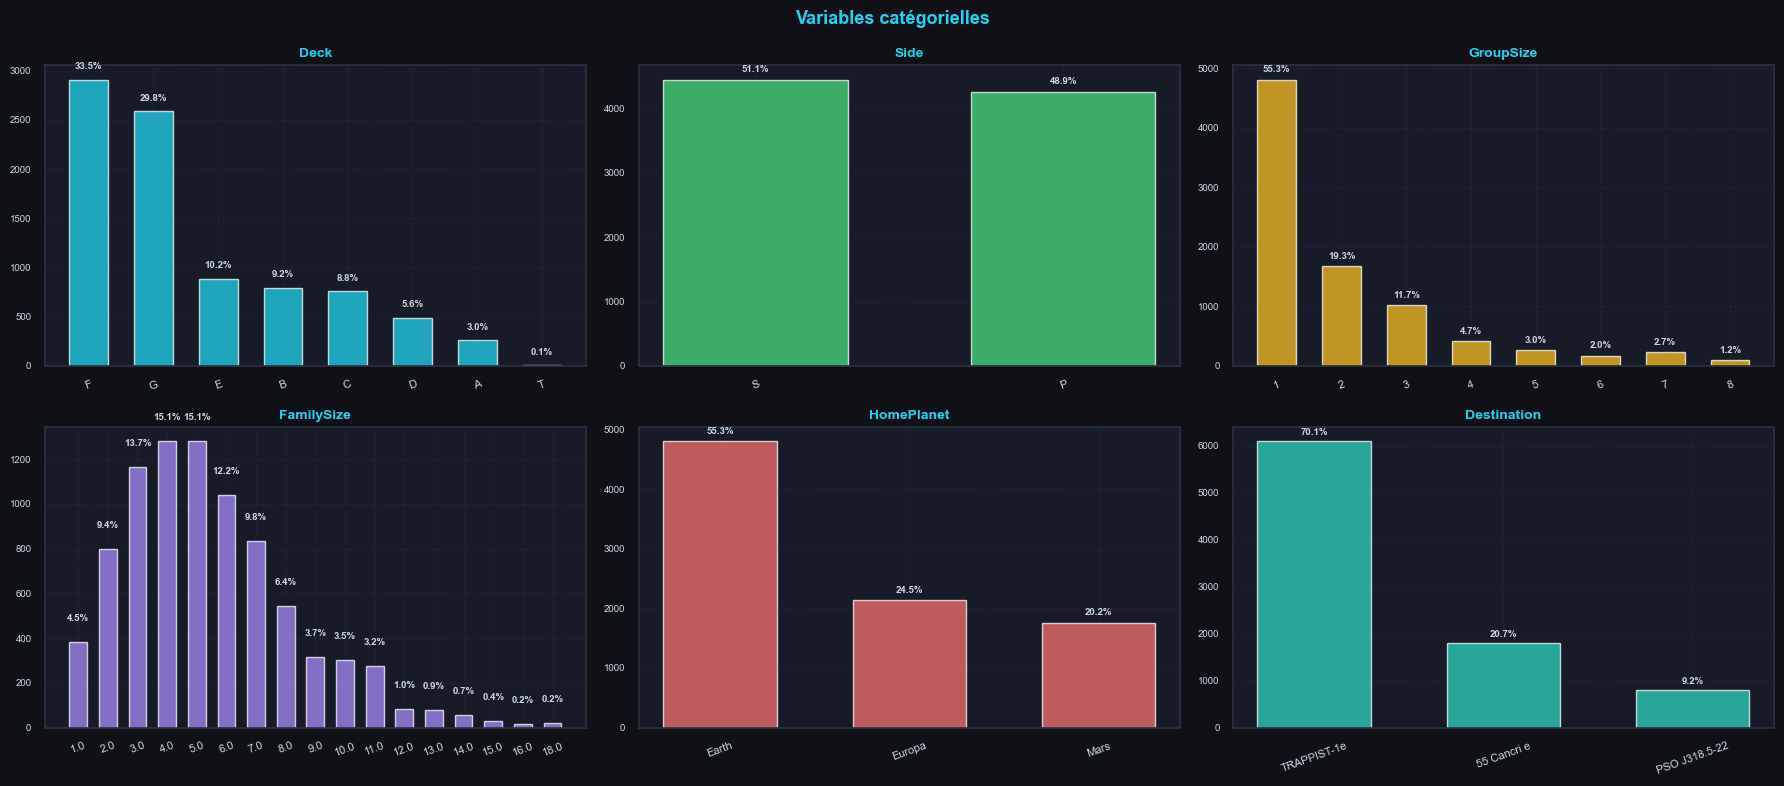

In [111]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. VARIABLES CATÉGORIELLES — % encima de cada barra
# ══════════════════════════════════════════════════════════════════════════════
cat_configs = [
    ('Deck',        COLORS['cyan'],   train_data['Deck'].value_counts().index),
    ('Side',        COLORS['green'],  train_data['Side'].value_counts().index),
    ('GroupSize',   COLORS['amber'],  sorted(train_data['GroupSize'].dropna().unique())),
    ('FamilySize',  COLORS['purple'], sorted(train_data['FamilySize'].dropna().unique())),
    ('HomePlanet',  COLORS['red'],    train_data['HomePlanet'].value_counts().index),
    ('Destination', COLORS['teal'],   train_data['Destination'].value_counts().index),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle("Variables catégorielles", fontsize=13, fontweight='bold', color=COLORS['cyan'])

for ax, (col, color, order) in zip(axes.flatten(), cat_configs):
    counts = train_data[col].value_counts().reindex(order).fillna(0)
    total_n = counts.sum()
    bars = ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.75, width=0.6)
    for bar, val in zip(bars, counts.values):
        pct = 100 * val / total_n
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total_n * 0.01,
                f"{pct:.1f}%",
                ha='center', va='bottom', fontsize=7,
                color=COLORS['text'], fontweight='bold')
    ax.set_title(col, fontsize=10, fontweight='bold', color=COLORS['cyan'])
    ax.tick_params(labelsize=8, axis='x', rotation=20, colors=COLORS['text'])
    ax.tick_params(labelsize=7, axis='y', colors=COLORS['text'])
    ax.set_facecolor(COLORS['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('eda_cat.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

### 2.1.3 Variables binaires

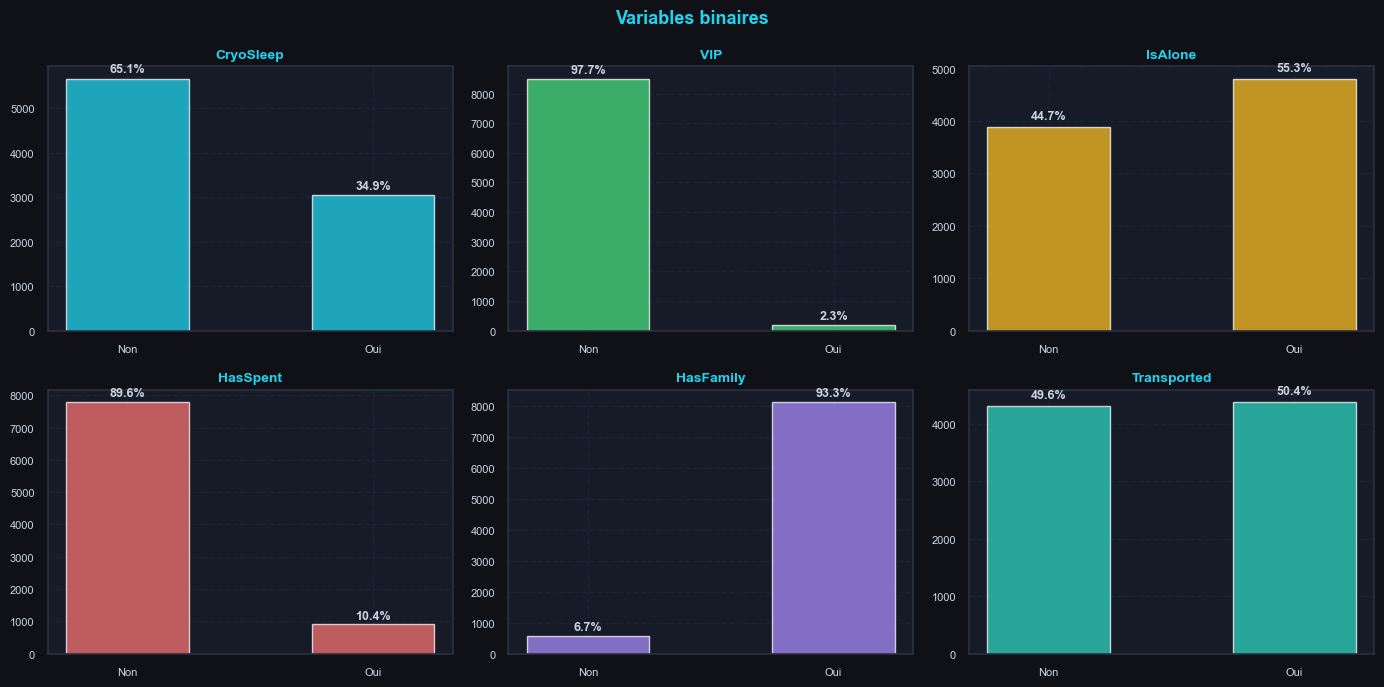

In [112]:

# ══════════════════════════════════════════════════════════════════════════════
# 5. VARIABLES BINAIRES — % encima de cada barra
# ══════════════════════════════════════════════════════════════════════════════
binary_vars = ['CryoSleep', 'VIP', 'IsAlone', 'HasSpent', 'HasFamily', 'Transported']
bin_colors  = [COLORS['cyan'], COLORS['green'], COLORS['amber'],
               COLORS['red'],  COLORS['purple'], COLORS['teal']]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle("Variables binaires", fontsize=13, fontweight='bold', color=COLORS['cyan'])

for ax, col, color in zip(axes.flatten(), binary_vars, bin_colors):
    counts  = train_data[col].value_counts().sort_index()
    total_n = counts.sum()
    labels  = ['Non' if str(v) == '0' else 'Oui' for v in counts.index]
    bars    = ax.bar(labels, counts.values, color=color, alpha=0.75, width=0.5)
    for bar, val in zip(bars, counts.values):
        pct = 100 * val / total_n
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total_n * 0.01,
                f"{pct:.1f}%",
                ha='center', va='bottom', fontsize=9,
                color=COLORS['text'], fontweight='bold')
    ax.set_title(col, fontsize=10, fontweight='bold', color=COLORS['cyan'])
    ax.tick_params(labelsize=8, colors=COLORS['text'])
    ax.set_facecolor(COLORS['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('eda_binary.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 2.2 Statistiques bivariées 

Verification de la coherence des données (cryogénisé et depenses)

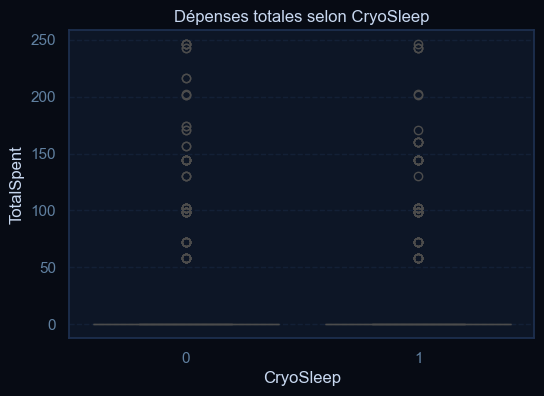

In [113]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train_data, x='CryoSleep', y='TotalSpent')
plt.title("Dépenses totales selon CryoSleep")
plt.show()


Analyse des relations entre variables catégorielles avec le V de Cramer

Nous analysons la force des relations entre les variables catégorielles à l'aide du V de Cramer et visualisons la matrice de corrélation obtenue. La diagonale est fixée à 1 pour une meilleure lisibilité.

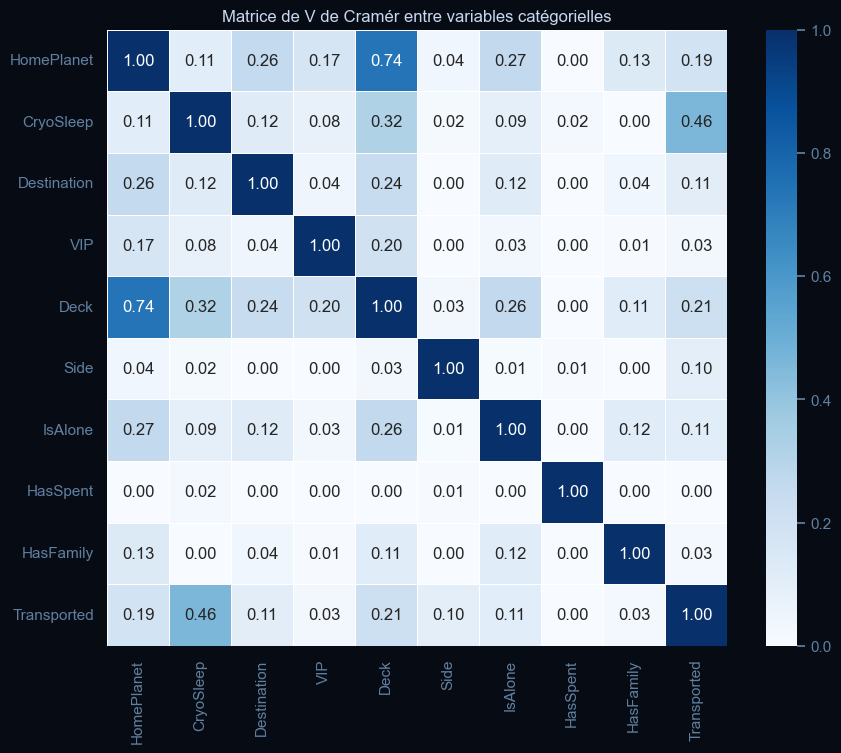

In [114]:
# ================================
# SELECTION DES VARIABLES CATEGORIELLES
# ================================
# Exclure les colonnes à trop forte cardinalité
cat_cols = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
    'Deck',
    'Side',
    'IsAlone',
    'HasSpent',
    'HasFamily',
    'Transported'
]

# ================================
# FONCTION V DE CRAMER
# ================================
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# ================================
# CALCUL DE LA MATRICE DE V DE CRAMER
# ================================
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(train_data[col1], train_data[col2])

cramer_matrix = cramer_matrix.astype(float)
np.fill_diagonal(cramer_matrix.values, 1)

# ================================
# HEATMAP
# ================================
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramer_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Matrice de V de Cramér entre variables catégorielles")
plt.show()

### 2.4 Croisements pertinents & Hypothèses

On croise les variables les plus discriminantes pour formuler des hypothèses interprétables.


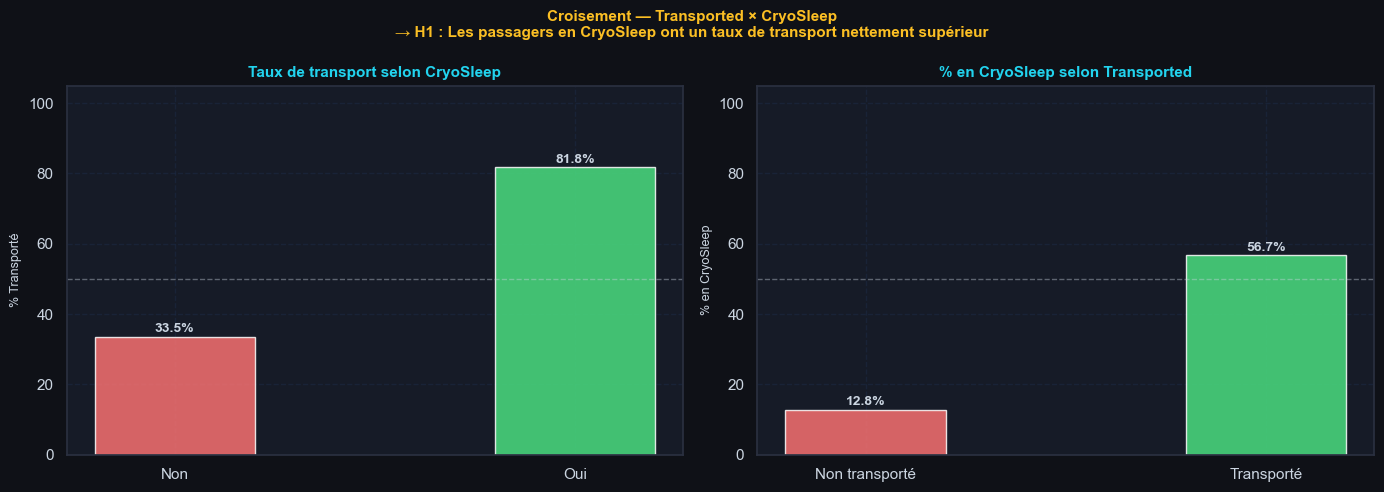

✓ Transported × CryoSleep :
              n  transport_rate
CryoSleep                      
0          5656           0.335
1          3037           0.818


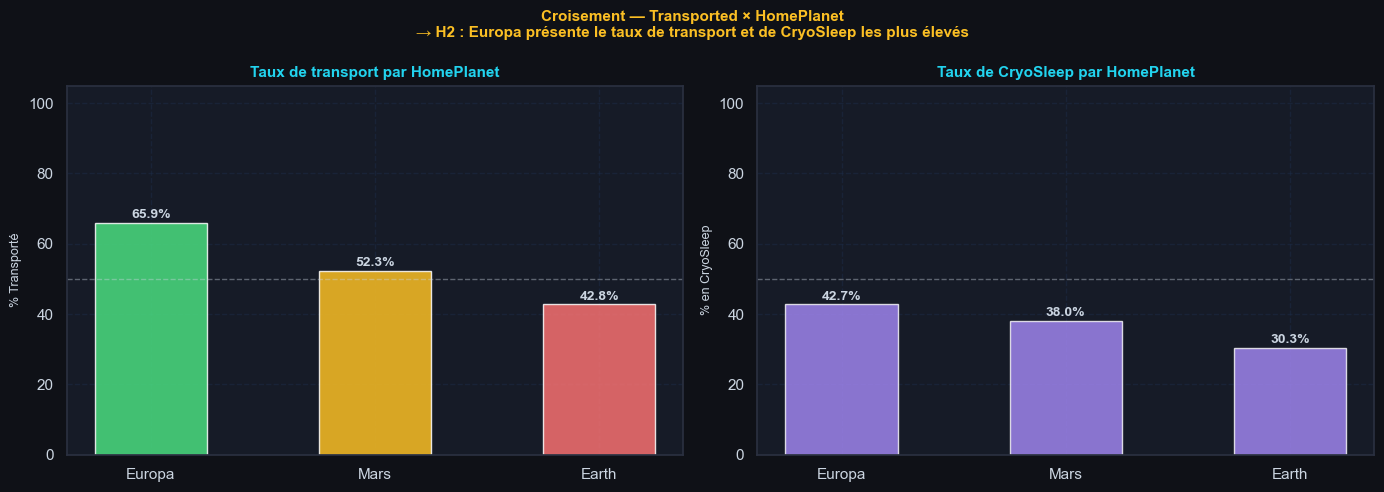

✓ Transported × HomePlanet :
               n  transport_rate  cryo_rate
HomePlanet                                 
Europa      2131           0.659      0.427
Mars        1759           0.523      0.380
Earth       4803           0.428      0.303


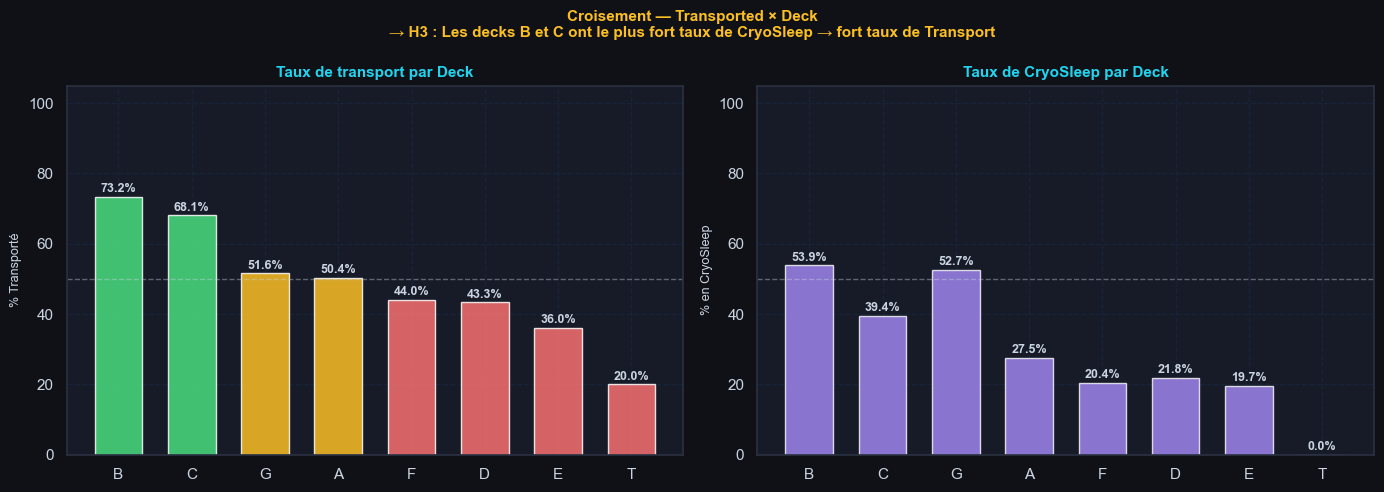

✓ Transported × Deck :
         n  transport_rate  cryo_rate
Deck                                 
B      796           0.732      0.539
C      761           0.681      0.394
G     2588           0.516      0.527
A      262           0.504      0.275
F     2909           0.440      0.204
D      487           0.433      0.218
E      885           0.360      0.197
T        5           0.200      0.000


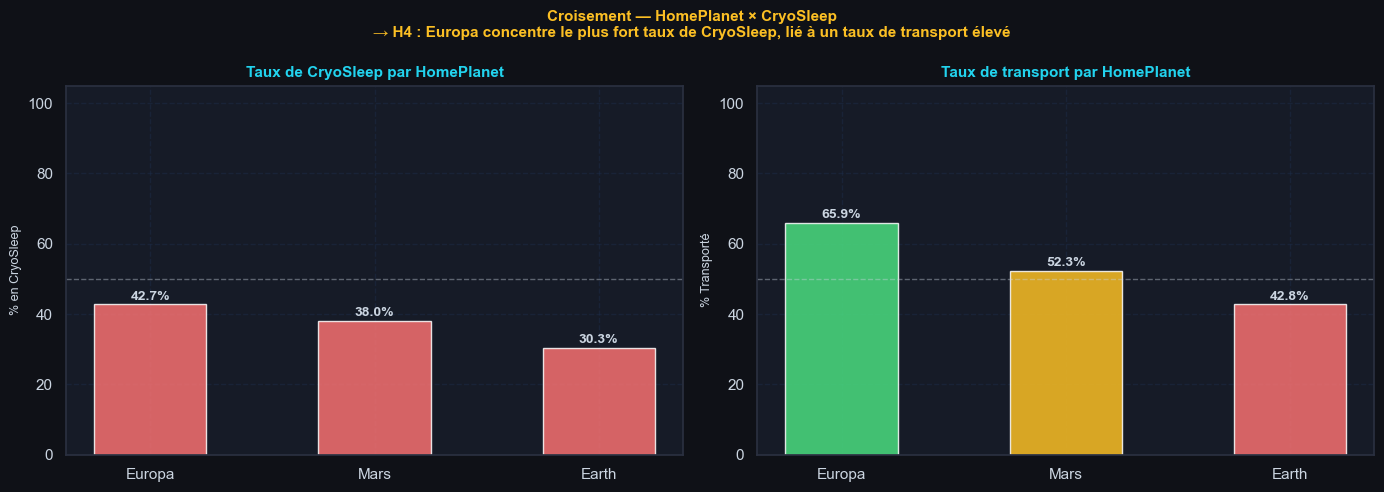

✓ HomePlanet × CryoSleep :
               n  cryo_rate  transport_rate
HomePlanet                                 
Europa      2131      0.427           0.659
Mars        1759      0.380           0.523
Earth       4803      0.303           0.428


KeyError: 'muted'

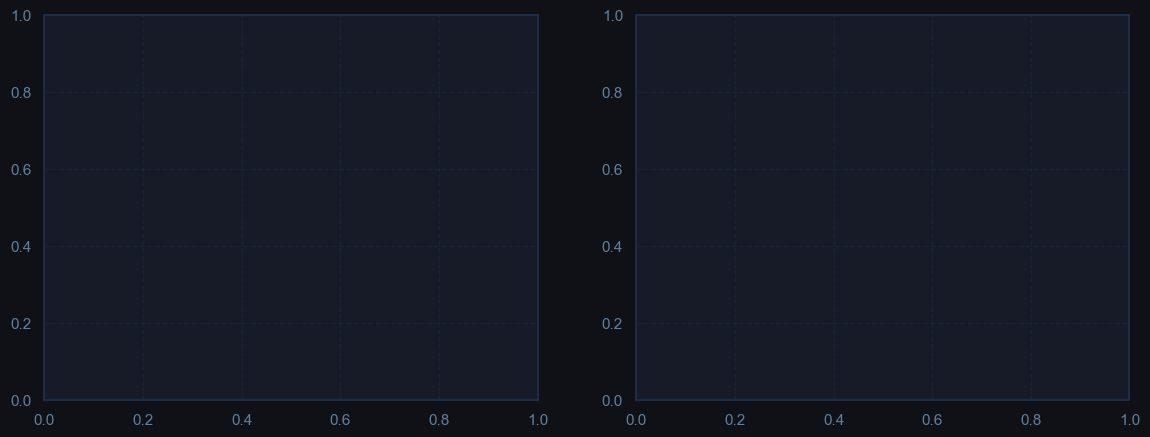

In [115]:
# ══════════════════════════════════════════════════════════════════════════════
# CROISEMENTS — Transported × (CryoSleep, HomePlanet, Deck)
# ══════════════════════════════════════════════════════════════════════════════

# ── Transported × CryoSleep ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

cryo_stats = train_data.groupby('CryoSleep').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count')
)  # pas de sort_values — ordre 0/1 préservé

colors_cryo = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in cryo_stats['transport_rate']]

bars = axes[0].bar(range(len(cryo_stats)), cryo_stats['transport_rate'] * 100,
                   color=colors_cryo, alpha=0.85, width=0.4)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(cryo_stats)))
axes[0].set_xticklabels(['Non' if str(v) == '0' else 'Oui' for v in cryo_stats.index],
                         color=COLORS['text'])
for bar, val in zip(bars, cryo_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport selon CryoSleep",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

cryo_transp = train_data.groupby('Transported')['CryoSleep'].mean() * 100
colors_t = ['Non' if str(v) == '0' else 'Oui' for v in cryo_transp.index]
bar_colors_t = [COLORS['red'], COLORS['green']]
bars2 = axes[1].bar(['Non transporté', 'Transporté'], cryo_transp.values,
                    color=bar_colors_t, alpha=0.85, width=0.4)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
for bar, val in zip(bars2, cryo_transp.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("% en CryoSleep selon Transported",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — Transported × CryoSleep\n"
             "→ H1 : Les passagers en CryoSleep ont un taux de transport nettement supérieur",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_transported_cryo.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ Transported × CryoSleep :")
print(cryo_stats[['n', 'transport_rate']].round(3).to_string())


# ── Transported × HomePlanet ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

planet_stats = train_data.groupby('HomePlanet').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count'),
    cryo_rate=('CryoSleep', 'mean')
).sort_values('transport_rate', ascending=False)

colors_planet = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                 else COLORS['red'] for v in planet_stats['transport_rate']]

bars = axes[0].bar(range(len(planet_stats)), planet_stats['transport_rate'] * 100,
                   color=colors_planet, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(planet_stats)))
axes[0].set_xticklabels(planet_stats.index, color=COLORS['text'])
for bar, val in zip(bars, planet_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

bars2 = axes[1].bar(range(len(planet_stats)), planet_stats['cryo_rate'] * 100,
                    color=COLORS['purple'], alpha=0.8, width=0.5)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(planet_stats)))
axes[1].set_xticklabels(planet_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, planet_stats['cryo_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de CryoSleep par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — Transported × HomePlanet\n"
             "→ H2 : Europa présente le taux de transport et de CryoSleep les plus élevés",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_transported_planet.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ Transported × HomePlanet :")
print(planet_stats[['n', 'transport_rate', 'cryo_rate']].round(3).to_string())


# ── Transported × Deck ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

deck_stats = train_data.groupby('Deck').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count'),
    cryo_rate=('CryoSleep', 'mean')
).sort_values('transport_rate', ascending=False)

colors_deck = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in deck_stats['transport_rate']]

bars = axes[0].bar(range(len(deck_stats)), deck_stats['transport_rate'] * 100,
                   color=colors_deck, alpha=0.85, width=0.65)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(deck_stats)))
axes[0].set_xticklabels(deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars, deck_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

bars2 = axes[1].bar(range(len(deck_stats)), deck_stats['cryo_rate'] * 100,
                    color=COLORS['purple'], alpha=0.8, width=0.65)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(deck_stats)))
axes[1].set_xticklabels(deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, deck_stats['cryo_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de CryoSleep par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — Transported × Deck\n"
             "→ H3 : Les decks B et C ont le plus fort taux de CryoSleep → fort taux de Transport",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_transported_deck.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ Transported × Deck :")
print(deck_stats[['n', 'transport_rate', 'cryo_rate']].round(3).to_string())


# ══════════════════════════════════════════════════════════════════════════════
# CROISEMENTS — HomePlanet × (CryoSleep, Deck, IsAlone)
# ══════════════════════════════════════════════════════════════════════════════

# ── HomePlanet × CryoSleep ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

hp_cryo_stats = train_data.groupby('HomePlanet').agg(
    cryo_rate=('CryoSleep', 'mean'),
    n=('CryoSleep', 'count'),
    transport_rate=('Transported', 'mean')
).sort_values('cryo_rate', ascending=False)

colors_hp_cryo = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                  else COLORS['red'] for v in hp_cryo_stats['cryo_rate']]

bars = axes[0].bar(range(len(hp_cryo_stats)), hp_cryo_stats['cryo_rate'] * 100,
                   color=colors_hp_cryo, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(hp_cryo_stats)))
axes[0].set_xticklabels(hp_cryo_stats.index, color=COLORS['text'])
for bar, val in zip(bars, hp_cryo_stats['cryo_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de CryoSleep par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_hp_t = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in hp_cryo_stats['transport_rate']]
bars2 = axes[1].bar(range(len(hp_cryo_stats)), hp_cryo_stats['transport_rate'] * 100,
                    color=colors_hp_t, alpha=0.85, width=0.5)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(hp_cryo_stats)))
axes[1].set_xticklabels(hp_cryo_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, hp_cryo_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — HomePlanet × CryoSleep\n"
             "→ H4 : Europa concentre le plus fort taux de CryoSleep, lié à un taux de transport élevé",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_homeplanet_cryo.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ HomePlanet × CryoSleep :")
print(hp_cryo_stats[['n', 'cryo_rate', 'transport_rate']].round(3).to_string())


# ── HomePlanet × Deck ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

hp_deck_stats = train_data.groupby('HomePlanet').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count'),
    deck_mode=('Deck', lambda x: x.mode()[0])
).sort_values('transport_rate', ascending=False)

hp_deck_pct = (train_data.groupby(['HomePlanet', 'Deck'])
               .size().unstack(fill_value=0)
               .reindex(hp_deck_stats.index))
hp_deck_pct = hp_deck_pct.div(hp_deck_pct.sum(axis=1), axis=0) * 100

# ✅ Uniquement des couleurs présentes dans ton COLORS
deck_colors = [COLORS['cyan'], COLORS['green'], COLORS['amber'], COLORS['red'],
               COLORS['purple'], COLORS['muted'], COLORS['text'], COLORS['border']]

colors_hp_d = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in hp_deck_stats['transport_rate']]
bars = axes[0].bar(range(len(hp_deck_stats)), hp_deck_stats['transport_rate'] * 100,
                   color=colors_hp_d, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(hp_deck_stats)))
axes[0].set_xticklabels(hp_deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars, hp_deck_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

bottom = np.zeros(len(hp_deck_pct))
for i, deck in enumerate(hp_deck_pct.columns):
    color = deck_colors[i % len(deck_colors)]
    bars2 = axes[1].bar(range(len(hp_deck_pct)), hp_deck_pct[deck],
                        bottom=bottom, color=color, alpha=0.85, width=0.5, label=deck)
    for bar, val, bot in zip(bars2, hp_deck_pct[deck], bottom):
        if val > 5:
            axes[1].text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                         f'{val:.1f}%', ha='center', va='center',
                         fontsize=8, color='#070b14', fontweight='bold')
    bottom += hp_deck_pct[deck].values

axes[1].set_xticks(range(len(hp_deck_pct)))
axes[1].set_xticklabels(hp_deck_pct.index, color=COLORS['text'])
axes[1].set_title("Répartition des Decks par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% passagers", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 115)
axes[1].tick_params(colors=COLORS['text'])
axes[1].legend(title='Deck', fontsize=8, title_fontsize=8,
               facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
               labelcolor=COLORS['text'], loc='upper right')
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — HomePlanet × Deck\n"
             "→ H5 : Les passagers d'Europa voyagent majoritairement sur des decks spécifiques",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_homeplanet_deck.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ HomePlanet × Deck :")
print(hp_deck_stats[['n', 'transport_rate', 'deck_mode']].round(3).to_string())


# ── HomePlanet × IsAlone ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

hp_alone_stats = train_data.groupby('HomePlanet').agg(
    alone_rate=('IsAlone', 'mean'),
    n=('IsAlone', 'count'),
    transport_rate=('Transported', 'mean')
).sort_values('alone_rate', ascending=False)

colors_alone = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                else COLORS['red'] for v in hp_alone_stats['alone_rate']]

bars = axes[0].bar(range(len(hp_alone_stats)), hp_alone_stats['alone_rate'] * 100,
                   color=colors_alone, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(hp_alone_stats)))
axes[0].set_xticklabels(hp_alone_stats.index, color=COLORS['text'])
for bar, val in zip(bars, hp_alone_stats['alone_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de voyage en solo par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% IsAlone", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_hp_t2 = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                else COLORS['red'] for v in hp_alone_stats['transport_rate']]
bars2 = axes[1].bar(range(len(hp_alone_stats)), hp_alone_stats['transport_rate'] * 100,
                    color=colors_hp_t2, alpha=0.85, width=0.5)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(hp_alone_stats)))
axes[1].set_xticklabels(hp_alone_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, hp_alone_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — HomePlanet × IsAlone\n"
             "→ H6 : Les passagers de Mars voyagent plus souvent seuls",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_homeplanet_alone.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ HomePlanet × IsAlone :")
print(hp_alone_stats[['n', 'alone_rate', 'transport_rate']].round(3).to_string())


# ══════════════════════════════════════════════════════════════════════════════
# CROISEMENTS — CryoSleep × (Deck, HasSpent)
# ══════════════════════════════════════════════════════════════════════════════

# ── CryoSleep × Deck ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

cryo_deck_stats = train_data.groupby('Deck').agg(
    cryo_rate=('CryoSleep', 'mean'),
    n=('CryoSleep', 'count'),
    transport_rate=('Transported', 'mean')
).sort_values('cryo_rate', ascending=False)

colors_cryo_deck = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                    else COLORS['red'] for v in cryo_deck_stats['cryo_rate']]

bars = axes[0].bar(range(len(cryo_deck_stats)), cryo_deck_stats['cryo_rate'] * 100,
                   color=colors_cryo_deck, alpha=0.85, width=0.65)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(cryo_deck_stats)))
axes[0].set_xticklabels(cryo_deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars, cryo_deck_stats['cryo_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de CryoSleep par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_cryo_t = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                 else COLORS['red'] for v in cryo_deck_stats['transport_rate']]
bars2 = axes[1].bar(range(len(cryo_deck_stats)), cryo_deck_stats['transport_rate'] * 100,
                    color=colors_cryo_t, alpha=0.85, width=0.65)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(cryo_deck_stats)))
axes[1].set_xticklabels(cryo_deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, cryo_deck_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — CryoSleep × Deck\n"
             "→ H7 : Les decks avec le plus fort taux de CryoSleep ont aussi le plus fort taux de transport",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_cryo_deck.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ CryoSleep × Deck :")
print(cryo_deck_stats[['n', 'cryo_rate', 'transport_rate']].round(3).to_string())


# ── CryoSleep × HasSpent ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

cryo_spent_stats = train_data.groupby('CryoSleep').agg(
    spent_rate=('HasSpent', 'mean'),
    n=('HasSpent', 'count'),
    transport_rate=('Transported', 'mean')
)  # pas de sort_values — ordre 0/1 préservé

colors_cryo_s = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                 else COLORS['red'] for v in cryo_spent_stats['spent_rate']]

bars = axes[0].bar(range(len(cryo_spent_stats)), cryo_spent_stats['spent_rate'] * 100,
                   color=colors_cryo_s, alpha=0.85, width=0.4)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(cryo_spent_stats)))
axes[0].set_xticklabels(
    ['Non' if str(v) == '0' else 'Oui' for v in cryo_spent_stats.index],
    color=COLORS['text'])
for bar, val in zip(bars, cryo_spent_stats['spent_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de dépenses (HasSpent) selon CryoSleep",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% HasSpent", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_cryo_t2 = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                  else COLORS['red'] for v in cryo_spent_stats['transport_rate']]
bars2 = axes[1].bar(range(len(cryo_spent_stats)), cryo_spent_stats['transport_rate'] * 100,
                    color=colors_cryo_t2, alpha=0.85, width=0.4)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(cryo_spent_stats)))
axes[1].set_xticklabels(
    ['Non' if str(v) == '0' else 'Oui' for v in cryo_spent_stats.index],
    color=COLORS['text'])
for bar, val in zip(bars2, cryo_spent_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport selon CryoSleep",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — CryoSleep × HasSpent\n"
             "→ H8 : Les passagers en CryoSleep ne dépensent pas → cohérence avec confinement en cabine",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.savefig('cross_cryo_spent.png', dpi=130, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("✓ CryoSleep × HasSpent :")
print(cryo_spent_stats[['n', 'spent_rate', 'transport_rate']].round(3).to_string())

# 3. Modelisation 

In [ ]:
train_data = train_data.drop(['PassengerId', 'Name'], axis=1)
test_data = test_data.drop(['PassengerId', 'Name'], axis=1)
train_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpent,HasSpent,FamilyName,FamilySize,HasFamily
0,Europa,0,TRAPPIST-1e,39.0,0,0,0,0,0,0,...,1,1,B,0,P,0,0,Ofracculy,1.0,0
1,Earth,0,TRAPPIST-1e,24.0,0,0,0,0,0,0,...,1,1,F,0,S,0,0,Vines,4.0,1
2,Europa,0,TRAPPIST-1e,58.0,1,0,0,0,0,0,...,2,0,A,0,S,0,0,Susent,6.0,1
3,Europa,0,TRAPPIST-1e,33.0,0,0,0,0,0,0,...,2,0,A,0,S,0,0,Susent,6.0,1
4,Earth,0,TRAPPIST-1e,16.0,0,0,0,0,0,0,...,1,1,F,1,S,0,0,Santantines,6.0,1


## 3.1 Définition des variables

In [ ]:

categorical_features = ['HomePlanet', 'Destination', 'Deck', 'Side']
numerical_features   = [
    'CryoSleep', 'Age', 'VIP',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'TotalSpent', 'HasSpent',
    'GroupSize', 'IsAlone',
    'FamilySize', 'HasFamily',
    'CabinNum'
]


# 3.2 Séparation features / cible

In [ ]:
X        = train_data.drop(columns=['Transported', 'Group', 'FamilyName'])
y        = train_data['Transported']
test_data = test_data.drop(columns=['Group', 'FamilyName'])

# Split interne du train pour évaluer les modèles pendant le développement
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape} ")
print(f"test_data: {test.shape}")

X_train : (6954, 21)
X_test  : (1739, 21) 


NameError: name 'tes' is not defined

In [ ]:
print("─" * 45)
print(f"  Exemples en entraînement  : {len(X_train):>6}")
print(f"  Exemples en validation    : {len(X_test):>6}")
print(f"  Exemples Test    : {len(X_kaggle_prepared):>6}")
print("─" * 45)

Examples in the train set: 6954.
Examples in the test set: 1739.


## 3.2 Entrainement des modèles 

### 3.2.1 Arbre de décision

Le classificateur par Arbre de Décision (Decision Tree Classifier) est un modèle simple et interprétable, particulièrement utile pour les problèmes présentant des relations complexes entre les variables d'entrée. Il segmente les données en fonction de la valeur des caractéristiques, créant ainsi une structure en forme d'arbre. Ce modèle est facile à comprendre et à visualiser, ce qui le rend idéal pour l'exploration initiale des données. Cependant, les arbres de décision sont sujets au surapprentissage (overfitting), en particulier lorsqu'ils sont profonds.

In [ ]:
# Create the model
model = DecisionTreeClassifier(max_depth=5, random_state=1)

# Train the model
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print("Accuracy of the Decision Tree Classifier:", score)
# What is the best value for max_depth?
max_depth_values = np.arange(1, 21)

# List to store the accuracies
accuracies = []

# Evaluate the model for each max_depth value
for depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

best_max_depth = max_depth_values[np.argmax(accuracies)]
print(f"Best value for max_depth: {best_max_depth}")
print(f"Precision for the best max_depth: {max(accuracies):.4f}")

# Create the best model
model_1_dtc = DecisionTreeClassifier(max_depth=7, random_state=1)

# Train the best model
model_1_dtc.fit(X_train, y_train)

Accuracy of the Decision Tree Classifier: 0.7331799884991375
Best value for max_depth: 4
Precision for the best max_depth: 0.7349


,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 3.2.2 Random Forest Classifier

La Forêt Aléatoire (Random Forest) est une méthode d'ensemble qui combine plusieurs arbres de décision pour réduire le risque de surapprentissage (overfitting) et augmenter la précision des prédictions. Chaque arbre de la forêt est entraîné sur un sous-ensemble aléatoire des données, et la prédiction finale est obtenue en faisant la moyenne des prédictions de tous les arbres (pour la régression) ou par un système de vote (pour la classification). Ce modèle est robuste face au surapprentissage, gère efficacement les jeux de données à haute dimension et s'avère performant aussi bien pour les tâches de classification que de régression. Les Random Forests ont tendance à offrir de bons résultats sans nécessiter un réglage excessif des hyperparamètres.

In [ ]:
# Create the model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=1)

# Train the model
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print("Accuracy of the Decision Tree Classifier:", score)

Accuracy of the Decision Tree Classifier: 0.7377803335250144


In [ ]:
# What are the best values for the parameters?
# Using GridSearchCV

# Define the model
model = RandomForestClassifier(random_state=1)

# Define the values to test
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [5, 10, 15, None],  # max_depth of the trees
    'min_samples_split': [2, 5, 10],  # Min number of required samples to divide a node
    'min_samples_leaf': [1, 2, 4],  # Min number of samples in a leaf
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider when dividing a node
}

# Use GridSearchCV to perform the search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=0)

# Fit the model
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

# Evaluate the model with the best params
best = grid_search.best_estimator_
y_pred = best.predict(X_test)
print("Accuracy with the best parameters:", accuracy_score(y_test, y_pred))

Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy with the best parameters: 0.7337550316273721


In [ ]:
# Create the model
model_2_rf = RandomForestClassifier(
    n_estimators=160, 
    max_depth=10, 
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    random_state=1
)

# Train the model
model_2_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prédictions

In [ ]:
y_pred_dtc = model_1_dtc.predict(X_test)

from sklearn.metrics import accuracy_score
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dtc))

In [ ]:
model_2_rf.fit(X_train, y_train)

y_pred_rf = model_2_rf.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))

In [ ]:
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dtc))
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))